## Chapter 4 - Cumulative Distribution Functions

#### 4.1. Percentiles and Percentile Ranks

In [2]:
import sys

sys.path.append('../nb')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from thinkstats import decorate

In [3]:
import os
os.chdir('../data')

from relay import read_results

results = read_results('Apr25_27thAn_set1.shtml')

os.chdir('../my-work')
results.head()

,Place,Div/Tot,Division,Guntime,Nettime,Min/Mile,MPH
0,1,1/362,M2039,30:43,30:42,4:57,12.121212
1,2,2/362,M2039,31:36,31:36,5:06,11.764706
2,3,3/362,M2039,31:42,31:42,5:07,11.726384
3,4,4/362,M2039,32:28,32:27,5:14,11.464968
4,5,5/362,M2039,32:52,32:52,5:18,11.320755


Use values to extract MPH as a numpy array

In [4]:
speeds = results["MPH"].values

my_result = results.query("Nettime == '42:44'")
my_result

,Place,Div/Tot,Division,Guntime,Nettime,Min/Mile,MPH
96,97,26/256,M4049,42:48,42:44,6:53,8.716707


In [5]:
# Get the actual index of your result
my_index = my_result.index[0]
my_speed = speeds[my_index]
my_speed


np.float64(8.716707021791768)

In [6]:
(speeds <= my_speed).sum()

np.int64(1537)

In [7]:
(speeds <= my_speed).mean() * 100

np.float64(94.12124923453766)

In [8]:
def percentile_rank(x, seq):
    """Percentile rank of x.

    x: value
    seq: sequence of values

    returns: percentile rank 0-100
    """
    return (seq <= x).mean() * 100

In [9]:
my_division = results.query("Division == 'M4049'")
my_division_speeds = my_division["MPH"].values

In [10]:
percentile_rank(my_speed, my_division_speeds)

np.float64(90.234375)

In [11]:
def percentile(p, seq):
    n = len(seq)
    i = (1 - p / 100) * (n + 1)
    return seq[round(i)]

In [12]:
percentile(90, my_division_speeds)

np.float64(8.591885441527447)

### 4.2. CDFs

A cumulative distribution function is another way to describe the distribution of a set of values, along with a frequency table or PMF. Given a value x, the CDF computes the fraction of values less than or equal to x. As an example, we’ll start with a short sequence.

In [13]:
t = [1, 2, 2, 3, 5]

In [14]:
from empiricaldist import Pmf

pmf = Pmf.from_seq(t)
pmf

,probs
1,0.2
2,0.4
3,0.2
5,0.2


In [15]:
pmf[2]

np.float64(0.4)

In [16]:
cdf = pmf.make_cdf()
cdf

,probs
1,0.2
2,0.6
3,0.8
5,1.0


In [17]:
cdf[2]

np.float64(0.6000000000000001)

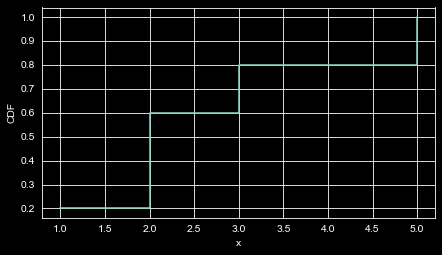

In [18]:
cdf.step()
decorate(xlabel="x", ylabel="CDF")

In [19]:
from empiricaldist import Cdf

cdf_speeds = Cdf.from_seq(speeds)

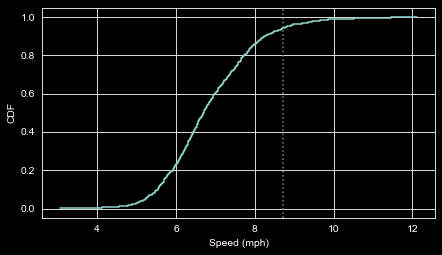

In [20]:
cdf_speeds.step()
plt.axvline(my_speed, ls=":", color="gray")
decorate(xlabel="Speed (mph)", ylabel="CDF")

In [21]:
cdf_speeds(my_speed) * 100

np.float64(94.12124923453766)

### 4.3. Comparing CDFs

In [22]:
from nsfg import get_nsfg_groups

os.chdir('../data')
live, firsts, others = get_nsfg_groups()
os.chdir('../my-work')


C:\Users\xannx\PycharmProjects\ThinkStats\my-work\../nb\nsfg.py:220: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["totalwgt_lb"] = df.birthwgt_lb + df.birthwgt_oz / 16.0


In [23]:
first_weights = firsts["totalwgt_lb"].dropna()
first_weights.mean()

np.float64(7.201094430437772)

In [24]:
other_weights = others["totalwgt_lb"].dropna()
other_weights.mean()

np.float64(7.325855614973262)

In [25]:
from empiricaldist import Pmf

first_pmf = Pmf.from_seq(first_weights, name="first")
other_pmf = Pmf.from_seq(other_weights, name="other")

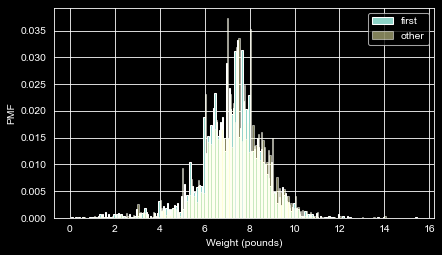

In [26]:
from thinkstats import two_bar_plots

two_bar_plots(first_pmf, other_pmf, width=0.06)
decorate(xlabel="Weight (pounds)", ylabel="PMF")

In [27]:
first_cdf = first_pmf.make_cdf()
other_cdf = other_pmf.make_cdf()

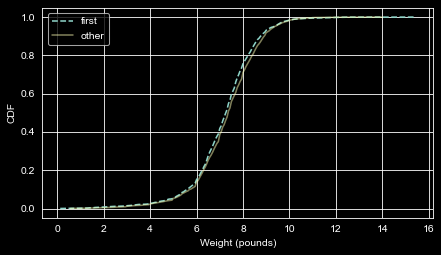

In [28]:
first_cdf.plot(ls="--")
other_cdf.plot(alpha=0.5)
decorate(xlabel="Weight (pounds)", ylabel="CDF")

### 4.4. Percentile-Based Statistics

In [29]:
from nsfg import read_stata

os.chdir('../data')

dct_file = "2002FemPreg.dct"
dat_file = "2002FemPreg.dat.gz"

preg = read_stata(dct_file, dat_file)

os.chdir('../my-work')


In [30]:
birthwgt_lb = preg["birthwgt_lb"]
birthwgt_oz = preg["birthwgt_oz"]

In [31]:
from empiricaldist import Hist

Hist.from_seq(birthwgt_oz).tail(5)

,freqs
birthwgt_oz,
14.0,475
15.0,378
97.0,1
98.0,1
99.0,46


In [32]:
birthwgt_lb_clean = birthwgt_lb.replace([51, 97, 98, 99], np.nan)
birthwgt_oz_clean = birthwgt_oz.replace([97, 98, 99], np.nan)

total_weight_clean = birthwgt_lb_clean + birthwgt_oz_clean / 16

In [33]:
total_weight_bogus = birthwgt_lb + birthwgt_oz / 16

In [34]:
std1, std2 = total_weight_bogus.std(), total_weight_clean.std()
std1, std2

(np.float64(2.096001779161835), np.float64(1.4082934455690173))

In [35]:
(std1 - std2) / std2 * 100

np.float64(48.83274403900607)

The standard deviation of the bogus data is off by almost 50%, so that’s more noticeable.

In [36]:
def skewness(seq):
    """Compute the skewness of a sequence

    seq: sequence of numbers

    returns: float skewness
    """
    deviations = seq - seq.mean()
    return np.mean(deviations**3) / seq.std(ddof=0) ** 3

In [37]:
skew1, skew2 = skewness(total_weight_bogus), skewness(total_weight_clean)
skew1, skew2

(np.float64(22.251846195422484), np.float64(-0.5895062687577698))

In [38]:
# how much is skew1 off by?
(skew1 - skew2) / skew2

np.float64(-38.74658112171127)

These results show that a small number of outliers have a moderate effect on the mean, a strong effect on the standard deviation, and a disastrous effect on skewness.

- An alternative is to use statistics based on percentiles. Specifically:

- The median, which is the 50th percentile, identifies a central point in a distribution, like the mean.

- The interquartile range, which is the difference between the 25th and 75th percentiles, quantifies the spread of the distribution, like the standard deviation.

- The quartile skewness uses the quartiles of the distribution (25th, 50th, and 75th percentiles) to quantify the skewness.

In [39]:
cdf_total_weight_bogus = Cdf.from_seq(total_weight_bogus)
cdf_total_weight_clean = Cdf.from_seq(total_weight_clean)

In [40]:
def iqr(cdf):
    low, high = cdf.inverse([0.25, 0.75])
    return high - low

In [41]:
iqr(cdf_total_weight_bogus), iqr(cdf_total_weight_clean)

(np.float64(1.625), np.float64(1.625))

In general, outliers have less effect on the IQR than on the standard deviation – in this case they have no effect at all.

Finally, here’s a function that computes quartile skewness, which depends on three statistics:

The median,

The midpoint of 25th and 75th percentiles, and

The semi-IQR, which is half of the IQR.

In [42]:
def quartile_skewness(cdf):
    low, median, high = cdf.inverse([0.25, 0.5, 0.75])
    midpoint = (high + low) / 2
    semi_iqr = (high - low) / 2
    return (midpoint - median) / semi_iqr

In [43]:
qskew1 = quartile_skewness(cdf_total_weight_bogus)
qskew2 = quartile_skewness(cdf_total_weight_clean)
qskew1, qskew2

(np.float64(-0.07692307692307693), np.float64(-0.07692307692307693))

### 4.7.1. Exercise 4.1

How much did you weigh at birth? If you don’t know, call your mother or someone else who knows. And if no one knows, you can use my birth weight, 8.5 pounds, for this exercise.

Using the NSFG data (all live births), compute the distribution of birth weights and use it to find your percentile rank. If you were a first baby, find your percentile rank in the distribution for first babies. Otherwise use the distribution for others. If you are in the 90th percentile or higher, call your mother back and apologize.

In [46]:
my_weight = 7.9

def percentile_rank(x, seq):
    """Percentile rank of x.

    x: value
    seq: sequence of values

    returns: percentile rank 0-100
    """
    return (seq <= x).mean() * 100

percentile_rank(my_weight, total_weight_clean)

np.float64(45.90598101964246)

### 4.7.2. Exercise 4.2

For live births in the NSFG dataset, the column babysex indicates whether the baby was male or female. We can use query to select the rows for male and female babies.

Make Cdf objects that represent the distribution of birth weights for male and female babies. Plot the two CDFs. What are the differences in the shape and location of the distributions?

If a male baby weighs 8.5 pounds, what is his percentile rank? What is the weight of a female baby with the same percentile rank?

In [49]:
male = live.query("babysex == 1")
female = live.query("babysex == 2")
len(male), len(female)

(4641, 4500)

In [52]:
male_weights = male["totalwgt_lb"].dropna()
female_weights = female["totalwgt_lb"].dropna()

pmf_male = Pmf.from_seq(male_weights, name="male")
pmf_female = Pmf.from_seq(female_weights, name="female")

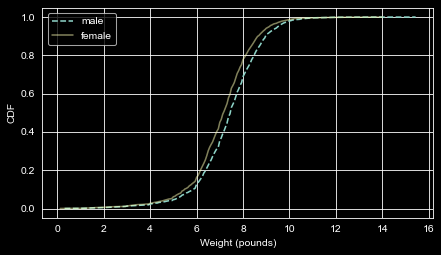

In [53]:
cdf_male = pmf_male.make_cdf()
cdf_female = pmf_female.make_cdf()

cdf_male.plot(ls="--", label="male")
cdf_female.plot(alpha=0.5, label="female")
decorate(xlabel="Weight (pounds)", ylabel="CDF")

In [54]:
# If a male baby weighs 8.5 pounds, what is his percentile rank?
male_weight = 8.5
male_percentile = cdf_male(male_weight) * 100
male_percentile

np.float64(80.65430752453653)

In [55]:
# What is the weight of a female baby with the same percentile rank?
female_weight = cdf_female.inverse(male_percentile / 100)
female_weight



array(8.1875)

### 4.7.3. Exercise 4.3

From the NSFG dataset pregnancy data, select the agepreg column and make a Cdf to represent the distribution of age at conception for each pregnancy. Use the CDF to compute the percentage of ages less than or equal to 20, and the percentage less than or equal to 30. Use those results to compute the percentage between 20 and 30.